In [1]:
!pip install qiskit
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 89.8 MB/s eta 0:00:00


In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

In [3]:
# Create circuit
qc = QuantumCircuit(3,3)

# Create entangled pair
qc.h(1)
qc.cx(1,2)

# State to teleport
qc.h(0)

# Alice operations
qc.cx(0,1)
qc.h(0)

# Measurements
qc.measure([0,1],[0,1])

# Bob corrections
qc.cx(1,2)
qc.cz(0,2)

# Final measurement
qc.measure(2,2)

qc.draw()

┌───┐          ┌───┐┌─┐           
q_0: ┤ H ├───────■──┤ H ├┤M├──────■────
     ├───┤     ┌─┴─┐└┬─┬┘└╥┘      │    
q_1: ┤ H ├──■──┤ X ├─┤M├──╫───■───┼────
     └───┘┌─┴─┐└───┘ └╥┘  ║ ┌─┴─┐ │ ┌─┐
q_2: ─────┤ X ├───────╫───╫─┤ X ├─■─┤M├
          └───┘       ║   ║ └───┘   └╥┘
c: 3/═════════════════╩═══╩══════════╩═
                      1   0          2

In [4]:
simulator = AerSimulator()

result = simulator.run(qc, shots=1024).result()

counts = result.get_counts()

print(counts)

{'101': 117, '001': 128, '111': 123, '011': 119, '010': 126, '000': 136, '100': 131, '110': 144}


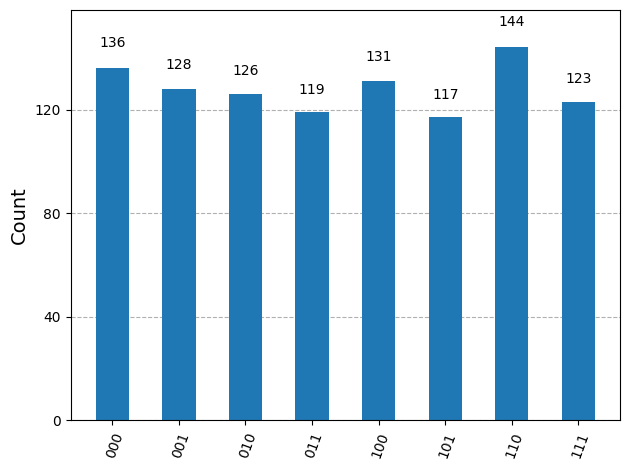

In [8]:
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

fig = plot_histogram(counts)
display(fig)